In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
import imblearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [2]:
data = pd.read_csv('../../Dataset/loan_prediction.csv')
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


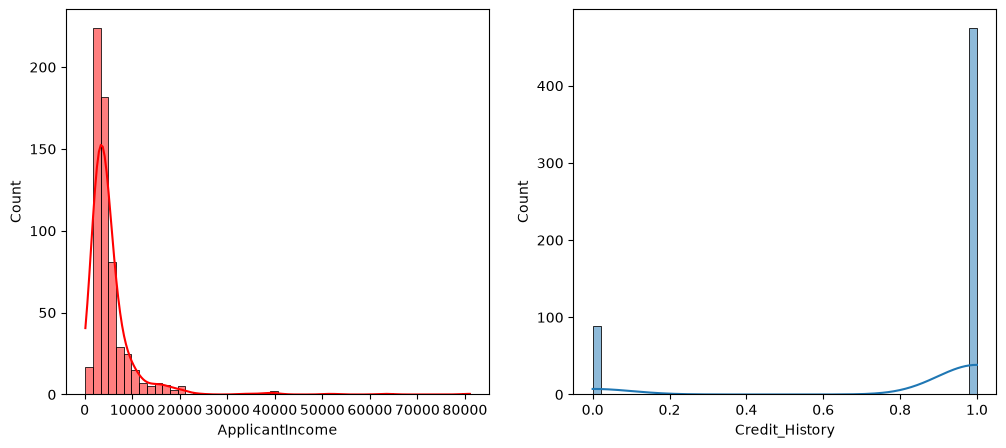

In [3]:
# Plotting using distplot
# Updated clean code without warnings
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.histplot(data['ApplicantIncome'], color='r', kde=True)
plt.subplot(122)
sns.histplot(data['Credit_History'], kde=True)
plt.show()

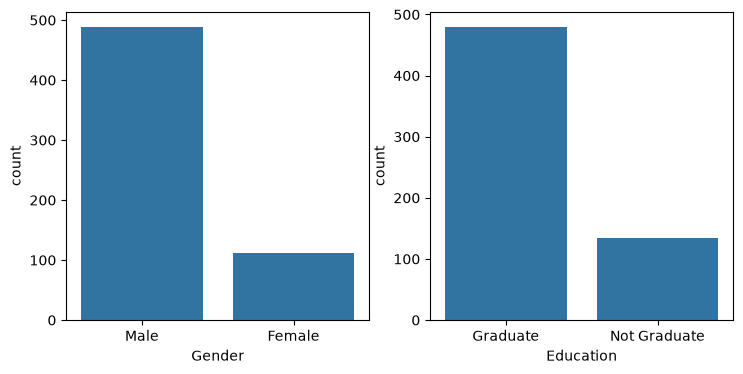

In [4]:
# plotting the count plot
plt.figure(figsize=(18,4))
plt.subplot(1,4,1)
sns.countplot(x=data['Gender'])
plt.subplot(1,4,2)
sns.countplot(x=data['Education'])
plt.show()

<Axes: xlabel='Property_Area', ylabel='count'>

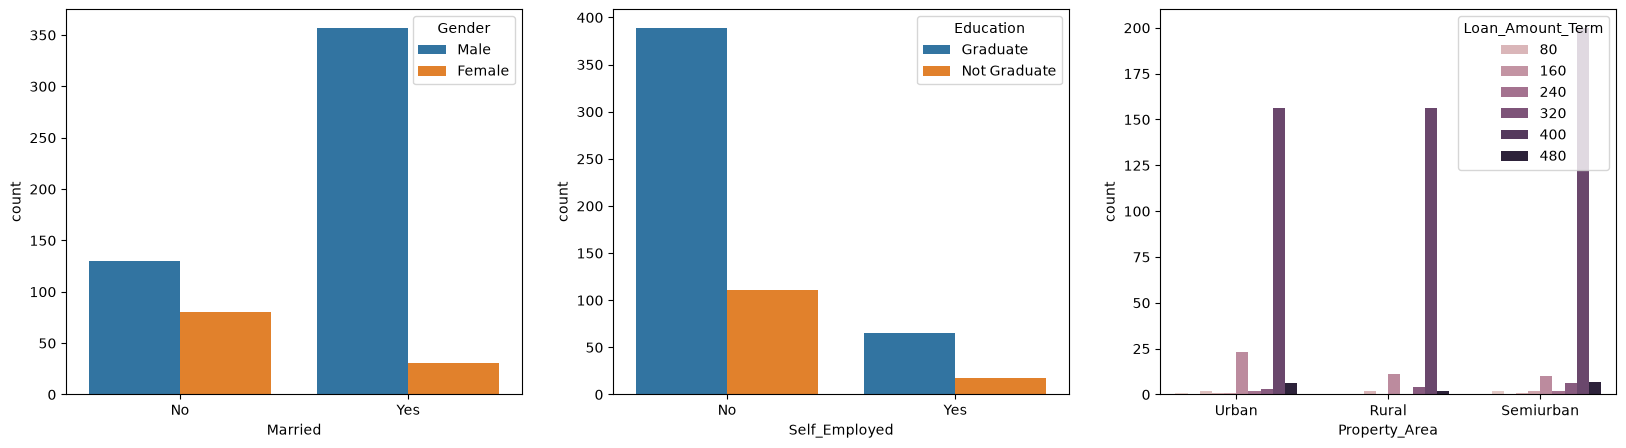

In [5]:
# visualising two columns against each other
plt.figure(figsize=(20,5))
plt.subplot(131)
sns.countplot(x=data['Married'], hue=data['Gender'])
plt.subplot(132)
sns.countplot(x=data['Self_Employed'], hue=data['Education'])
plt.subplot(133)
sns.countplot(x=data['Property_Area'], hue=data['Loan_Amount_Term'])

import matplotlib.pyplot as plt

# 1. Make the figure wider to give dots room to spread out
plt.figure(figsize=(10, 6))

# 2. Decrease the marker size (size=3) so they don't overlap as much
sns.swarmplot(x=data['Gender'], y=data['ApplicantIncome'], hue=data['Loan_Status'], size=3)

plt.show()

<Axes: xlabel='Gender', ylabel='ApplicantIncome'>

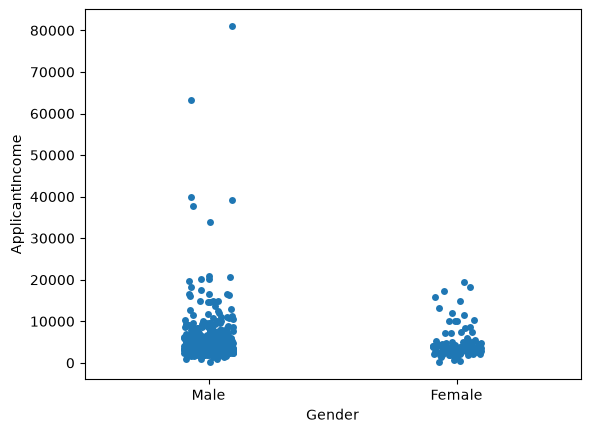

In [7]:
sns.stripplot(x=data['Gender'], y=data['ApplicantIncome'],jitter=True)

<Axes: xlabel='Gender', ylabel='ApplicantIncome'>

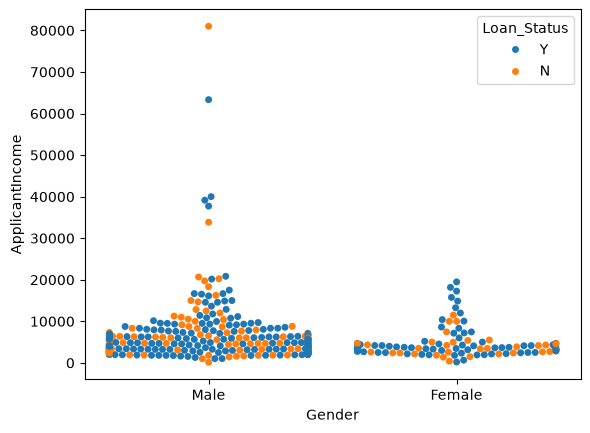

In [8]:
import warnings
warnings.filterwarnings('ignore')

# Your plotting code below
sns.swarmplot(x=data['Gender'], y=data['ApplicantIncome'], hue=data['Loan_Status'])

In [9]:
# finding the sum of null values in each column
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])

In [11]:
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])

In [12]:
# replacing + with space for filling the null values
data['Dependents'] = data['Dependents'].str.replace('+', '')

In [13]:
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode() [0])

In [14]:
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])

In [15]:
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].mode()[0])

In [16]:
# check remaining null values
data.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [17]:
# getting the total info of the data after performing categoricial
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    str    
 2   Married            614 non-null    str    
 3   Dependents         614 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      614 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [18]:
data['Gender'] = data['Gender'].map({'Female': 1, 'Male': 0})
data['Property_Area'] = data['Property_Area'].map({'Urban': 2, 'Semiurban': 1, 'Rural': 0})
data['Married'] = data['Married'].map({'Yes': 1, 'No': 0})
data['Education'] = data['Education'].map({'Graduate': 1, 'Not Graduate': 0})
data['Loan_Status'] = data['Loan_Status'].map({'Y': 1, 'N': 0})

In [19]:
# Handling categorical feature: Gender
data['Gender'] = data['Gender'].map({'Female': 1, 'Male': 0})
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,NaN,0,0,1,No,5849,0.0,120.0,360.0,1.0,2,1
1,LP001003,NaN,1,1,1,No,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,NaN,1,0,1,Yes,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,NaN,1,0,0,No,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,NaN,0,0,1,No,6000,0.0,141.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,NaN,0,0,1,No,2900,0.0,71.0,360.0,1.0,0,1
610,LP002979,NaN,1,3,1,No,4106,0.0,40.0,180.0,1.0,0,1
611,LP002983,NaN,1,1,1,No,8072,240.0,253.0,360.0,1.0,2,1
612,LP002984,NaN,1,2,1,No,7583,0.0,187.0,360.0,1.0,2,1


In [20]:
data['Property_Area'] = data['Property_Area'].map({'Urban': 2, 'Semiurban': 1, 'Rural': 0})

In [21]:
#changing the datatype of each float column to int
data['Gender']=data['Gender'].fillna(0).astype('Int64')
data['Married']=data['Married'].fillna(0).astype('Int64')
data['Dependents']=data['Dependents'].astype('Int64')
data['Self_Employed']=data['Self_Employed'].map({'Yes':1,'No':0}).astype('Int64')
data['CoapplicantIncome']=data['CoapplicantIncome'].astype('int64')
data['LoanAmount']=data['LoanAmount'].astype('Int64')
data['Loan_Amount_Term']=data['Loan_Amount_Term'].astype('Int64')
data['Credit_History']=data['Credit_History'].astype('Int64')

In [22]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    Int64  
 2   Married            614 non-null    Int64  
 3   Dependents         614 non-null    Int64  
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    Int64  
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    int64  
 8   LoanAmount         614 non-null    Int64  
 9   Loan_Amount_Term   600 non-null    Int64  
 10  Credit_History     564 non-null    Int64  
 11  Property_Area      0 non-null      float64
 12  Loan_Status        614 non-null    int64  
dtypes: Int64(7), float64(1), int64(4), str(1)
memory usage: 66.7 KB


In [23]:
# 1. Recreate X and y safely
X = data.drop(columns=['Loan_Status', 'Loan_ID'], errors='ignore')
y = data['Loan_Status']

# 2. Encode remaining text columns into numbers
if 'Education' in X.columns:
    X['Education'] = X['Education'].map({'Graduate': 1, 'Not Graduate': 0})

if 'Property_Area' in X.columns:
    X['Property_Area'] = X['Property_Area'].map({'Urban': 2, 'Semiurban': 1, 'Rural': 0})

# 3. Fill missing values for ALL categorical columns (including Property_Area and Education)
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']
for col in categorical_cols:
    if col in X.columns:
        mode_series = X[col].mode()
        fill_value = mode_series.iloc[0] if not mode_series.empty else 0
        X[col] = X[col].fillna(fill_value)

# 4. Fill missing values for continuous numeric columns
numerical_cols = ['LoanAmount', 'Loan_Amount_Term', 'ApplicantIncome', 'CoapplicantIncome']
for col in numerical_cols:
    if col in X.columns:
        fill_value = X[col].median()
        X[col] = X[col].fillna(fill_value if not pd.isna(fill_value) else 0)

# 5. Convert EVERYTHING to standard float for SMOTE compatibility
X = X.astype(float)

# 6. VERIFY: Ensure absolutely zero NaN values remain
print("Missing values remaining in X:")
print(X.isnull().sum())

Missing values remaining in X:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

In [25]:
# 1. Creating new X and y variables for the balanced set
X_bal, y_bal = smote.fit_resample(X, y)

In [26]:
# 2. Printing the values of y before balancing the data and after
print(y.value_counts())
print(y_bal.value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64
Loan_Status
1    422
0    422
Name: count, dtype: int64


In [27]:
# 3. Saving the column names from the balanced dataset
names = X_bal.columns

In [28]:
sc = StandardScaler()
X_bal_scaled = sc.fit_transform(X_bal)

In [29]:
X_bal = pd.DataFrame(X_bal_scaled, columns=names)

In [30]:
X_bal.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,0.0,-1.359344,-0.758576,0.0,-0.405476,0.111691,-0.584590,-0.304611,0.286778,0.572872,0.0
1,0.0,0.800017,0.289037,0.0,-0.405476,-0.119073,-0.024531,-0.205150,0.286778,0.572872,0.0
2,0.0,0.800017,-0.758576,0.0,2.674786,-0.407619,-0.584590,-0.975972,0.286778,0.572872,0.0
3,0.0,0.800017,-0.758576,0.0,-0.405476,-0.483629,0.291152,-0.304611,0.286778,0.572872,0.0
4,0.0,-1.359344,-0.758576,0.0,-0.405476,0.139215,-0.584590,-0.043526,0.286778,0.572872,0.0


In [31]:
# 1. Clean and split features safely
X = data.drop(columns=['Loan_Status', 'Loan_ID'], errors='ignore').copy()
y = data['Loan_Status']

# 2. Map all text variables to numbers safely
mapping_dict = {
    'Gender': {'Male': 1, 'Female': 0},
    'Married': {'Yes': 1, 'No': 0},
    'Education': {'Graduate': 1, 'Not Graduate': 0},
    'Self_Employed': {'Yes': 1, 'No': 0},
    'Property_Area': {'Urban': 2, 'Semiurban': 1, 'Rural': 0}
}

for col, mapping in mapping_dict.items():
    if col in X.columns:
        X[col] = X[col].map(mapping)

# 3. Fill any missing values with mode (categorical) or median (numerical)
for col in X.columns:
    if X[col].isnull().any():
        if col in mapping_dict or col == 'Credit_History' or col == 'Dependents':
            # Use mode scalar value
            mode_val = X[col].mode()
            fill_val = mode_val.iloc[0] if not mode_val.empty else 0
            X[col] = X[col].fillna(fill_val)
        else:
            # Use median scalar value
            median_val = X[col].median()
            X[col] = X[col].fillna(median_val if not pd.isna(median_val) else 0)

# 4. Clean Dependents column if it has text like '3+'
if 'Dependents' in X.columns:
    X['Dependents'] = X['Dependents'].astype(str).str.replace('+', '', regex=False)
    X['Dependents'] = pd.to_numeric(X['Dependents'], errors='coerce').fillna(0)

# 5. Convert to float and force fill any leftover NaN anomalies to 0
X = X.astype(float).fillna(0)

# 6. VERIFY: This must print all zeros!
print("Remaining NaNs:")
print(X.isnull().sum())

Remaining NaNs:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


In [32]:
X_bal, y_bal = smote.fit_resample(X, y)

In [33]:
#splitting the dataset in train and test on balnmced datasew
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.33, random_state=42)

In [34]:
X_train.shape

(565, 11)

In [35]:
X_test.shape

(279, 11)

In [36]:
def decisionTree(X_train,X_test,y_train,y_test):
    model = DecisionTreeClassifier()
    model.fit(X_train,y_train)
    y_tr = model.predict(X_train)
    print(accuracy_score(y_tr,y_train))
    yPred = model.predict(X_test)
    print(accuracy_score(yPred,y_test))

In [37]:
decisionTree(X_train,X_test,y_train,y_test)

1.0
0.7634408602150538


In [38]:
def RandomForest(X_tarin,X_test,y_train,y_test):
    model = RandomForestClassifier()
    model.fit(X_train,y_train)
    y_tr = model.predict(X_train)
    print(accuracy_score(y_tr,y_train))
    yPred = model.predict(X_test)
    print(accuracy_score(yPred,y_test))

In [39]:
RandomForest(X_train,X_test,y_train,y_test)

1.0
0.7921146953405018


In [40]:
def KNN(X_train,X_test,y_train,y_test):
    model = KNeighborsClassifier()
    model.fit(X_train,y_train)
    y_tr = model.predict(X_train)
    print(accuracy_score(y_tr,y_train))
    yPred = model.predict(X_test)
    print(accuracy_score(yPred,y_test))

In [41]:
KNN(X_train,X_test,y_train,y_test)

0.7539823008849558
0.6272401433691757


In [42]:
#importing and building the Xg boost model
def XGB(X_train,X_test,y_train,y_test):
    model = GradientBoostingClassifier()
    model.fit(X_train,y_train)
    y_tr = model.predict(X_train)
    print(accuracy_score(y_tr,y_train))
    yPred = model.predict(X_test)
    print(accuracy_score(yPred,y_test))
    return model

In [43]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
model =XGB(X_train_scaled,X_test_scaled,y_train,y_test)

0.9221238938053097
0.7670250896057348


In [45]:
import pickle
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize a completely new model variable name
final_model = RandomForestClassifier()

# 2. Fit the model directly
final_model.fit(X_train_scaled, y_train)

# 3. Save it as 'rdf.pkl'
with open("rdf.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("Model successfully saved!")

Model successfully saved!


In [46]:
%pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 882.3 kB/s eta 0:01:19
   ---------------------------------------- 0.8/69.5 MB 920.5 kB/s eta 0:01:15
   ---------------------------------------- 0.8/69.5 MB 920.5 kB/s eta 0:01:15
    --------------------------------------- 1.0/69.5 MB 935.8 kB/s eta 0:01:14
    --------------------------------------- 1.3/69.5 MB 976.0 kB/s eta 0:01:10
    --------------------------------------- 1.6/69.5 MB 1.0 MB/s eta 0:01:07
   - -------------------------------------- 2.1/69.5 MB 1.1 MB/s eta 0:01:01
   - -------------------------------------- 2.4/69.5 MB 1.1 MB/s eta 0:01:00
   - -------------------------------------- 2.9/69.5 MB 1.2 MB/s eta 0:00:54
   - ------------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
import pickle

with open("rdf.pkl", "wb") as f:
    pickle.dump(model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [48]:

import pickle

m = pickle.load(open("rdf.pkl", "rb"))
print(m)

GradientBoostingClassifier()


In [49]:
import pickle

with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)
    pickle.dump(scaler,open('scaler.pkl','wb'))

In [50]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

In [51]:
from sklearn.ensemble import RandomForestClassifier # (or whichever model you used)

# 1. Initialize the model object
model = RandomForestClassifier()

# 2. Train the model (fit it)
model.fit(X_train, y_train)

# 3. Export the model object carefully
import pickle
with open("rdf.pkl", "wb") as f:
    pickle.dump(model, f)  # Make sure 'model' is the actual trained object!

In [52]:
import pickle
from sklearn.ensemble import RandomForestClassifier

# 1. Create the model object
model = RandomForestClassifier()

# 2. Train (Fit) the model
model.fit(X_train, y_train)

# 3. Save the model as 'rdf.pkl' (Make sure to pass only 'model' here)
pickle.dump(model, open("rdf.pkl", "wb"))

In [53]:
import pickle

# 1. Train the model directly without assigning it to another variable
model.fit(X_train, y_train)

# 2. Now save the 'model' object cleanly using the following block
with open("rdf.pkl", "wb") as f:
    pickle.dump(model, f)

In [54]:
print(model)

RandomForestClassifier()


In [55]:
print(type(model))
print(model)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
RandomForestClassifier()


In [56]:
import pickle

pickle.dump(model, open("rdf.pkl", "wb"))
pickle.dump(scale, open("scaler.pkl", "wb"))

In [57]:
import pickle

model = pickle.load(open("rdf.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

print(model)
print(scaler)

RandomForestClassifier()
StandardScaler()


In [58]:
import pickle

# 1. Directly train the model object (do NOT set model = model.fit(...))
model.fit(X_train_scaled, y_train)

# 2. Save the trained model cleanly
with open("rdf.pkl", "wb") as f:
    pickle.dump(model, f)

# 3. Save your trained scaler cleanly
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)